# Assignment 2: MNIST Classification pipeline
**Roll Number:** 2023090

This notebook demonstrates the mathematical implementation of PCA, FDA, and Discriminant Classifiers (LDA & QDA) using NumPy.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Set random seed for reproducibility
np.random.seed(42)

### Step 1: Data Preprocessing
1. Load the MNIST dataset and filter for digits `0`, `1`, and `2`.
2. Randomly sample 100 images per class for training and testing ($N=300$).
3. Transform images into feature vectors via column stacking.
4. Normalize pixel values to the range `[0, 1]`.

In [9]:
# Load Data
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_raw, y_raw = mnist.data.astype('float32'), mnist.target.astype(int)

# Train/Test Split (as per standard MNIST definition)
X_train_full, y_train_full = X_raw[:60000], y_raw[:60000]
X_test_full, y_test_full = X_raw[60000:], y_raw[60000:]

def process_data(X_input, y_input):
    """Filters target classes, samples 100 per class, performs column stacking."""
    mask = np.isin(y_input, [0, 1, 2])
    X_filtered, y_filtered = X_input[mask], y_input[mask]

    indices = []
    for c in [0, 1, 2]:
        class_indices = np.where(y_filtered == c)[0]
        indices.extend(np.random.choice(class_indices, 100, replace=False))
    
    X_sampled, y_sampled = X_filtered[indices], y_filtered[indices]

    # Stacking columns
    X_images = X_sampled.reshape(-1, 28, 28)
    X_col_stacked = X_images.transpose(0, 2, 1).reshape(-1, 784)
    X_norm = X_col_stacked / 255.0  # Normalize to [0, 1]
    
    return X_norm, y_sampled

print("Sampling and Preprocessing Data...")
X_train_orig, y_train = process_data(X_train_full, y_train_full)
X_test_orig, y_test = process_data(X_test_full, y_test_full)

# Obtain data matrix X
X = X_train_orig.T
X_test = X_test_orig.T

print(f"Train data shape: {X.shape}, Test data shape: {X_test.shape}")

Fetching MNIST dataset...
Sampling and Preprocessing Data...
Train data shape: (784, 300), Test data shape: (784, 300)


### Step 2: Discriminant Analysis Classifiers (LDA and QDA)
Implementing the Maximum Likelihood Estimates (MLE) for mean $\mu_c$ and covariance $\Sigma_c$.

In [10]:
def compute_mle_estimates(X, y, classes):
    """
    Computes Maximum Likelihood Estimates for Mean, Covariance, and Priors.
    """
    mle_params = {}
    n_features = X.shape[1]
    total_samples = len(y)
    
    for c in classes:
        X_c = X[y == c]
        N_c = X_c.shape[0]
        
        # 1. Mean Vector
        mu_c = np.mean(X_c, axis=0).reshape(-1, 1)
        
        # 2. Covariance Matrix
        X_centered = X_c - mu_c.T
        sigma_c = (X_centered.T @ X_centered) / N_c
        
        # 3. Regularization 
        epsilon = 1e-4 
        sigma_c += epsilon * np.eye(n_features)
        
        # 4. Prior Probability
        prior_c = N_c / total_samples
        
        mle_params[c] = {
            'mu': mu_c,
            'sigma': sigma_c,
            'prior': prior_c
        }
        
    return mle_params

def get_pooled_covariance(mle_params):
    """Calculates pooled covariance for LDA"""
    first_class = list(mle_params.keys())[0]
    pooled_sigma = np.zeros_like(mle_params[first_class]['sigma'])
    
    for c in mle_params:
        pooled_sigma += mle_params[c]['prior'] * mle_params[c]['sigma']
        
    return pooled_sigma

def lda_discriminant(x, mu, sigma_inv, log_prior):
    """LDA Discriminant Function"""
    w = sigma_inv @ mu
    term1 = w.T @ x.reshape(-1, 1)
    term2 = -0.5 * (mu.T @ sigma_inv @ mu)
    return (term1 + term2 + log_prior).item()

def qda_discriminant(x, mu, sigma_inv, log_det, log_prior):
    """QDA Discriminant Function"""
    diff = x.reshape(-1, 1) - mu
    term1 = -0.5 * (diff.T @ sigma_inv @ diff)
    term2 = -0.5 * log_det
    return (term1 + term2 + log_prior).item()

def classify(X, mle_params, method='QDA', return_scores=False):
    """Classifies a dataset X using LDA or QDA estimators"""
    classes = sorted(list(mle_params.keys()))
    y_pred = []
    all_scores = []
    
    if method == 'LDA':
        sigma_shared = get_pooled_covariance(mle_params)
        sigma_inv = np.linalg.inv(sigma_shared)

    for x in X:
        scores =[]
        for c in classes:
            mu = mle_params[c]['mu']
            log_prior = np.log(mle_params[c]['prior'])
            
            if method == 'LDA':
                score = lda_discriminant(x, mu, sigma_inv, log_prior)
            else:
                sigma = mle_params[c]['sigma']
                s_inv = np.linalg.inv(sigma)
                _, log_det = np.linalg.slogdet(sigma)
                score = qda_discriminant(x, mu, s_inv, log_det, log_prior)
                
            scores.append(score)
            
        y_pred.append(classes[np.argmax(scores)])
        all_scores.append(scores)
        
    if return_scores:
        return np.array(y_pred), all_scores
    return np.array(y_pred)

def calculate_accuracy(y_true, y_pred):
    """Accuracy = Total Correct / Total Samples"""
    return np.mean(y_true == y_pred)

### Step 3: Principal Component Analysis (PCA)
1. Center the data $X_c = X - \mu$.
2. Compute unbiased sample covariance $S = \frac{1}{N-1}X_c X_c^T$.
3. Compute Eigen decomposition.
4. Extract projection matrix $U_p$ retaining 75% and 90% variance thresholds.
5. Project a single test point, extract discriminant values, and reconstruct 5 sample images to observe PCA visual fidelity.


Executing PCA...

Evaluating Single Test Point (Index 0) using 75% PCA + LDA:
True Label: 0
Discriminant Values [Class 0, Class 1, Class 2]: [-0.18809507293935002, -14.470474700167133, -5.302424411013081]
Predicted Class (Max Value): 0


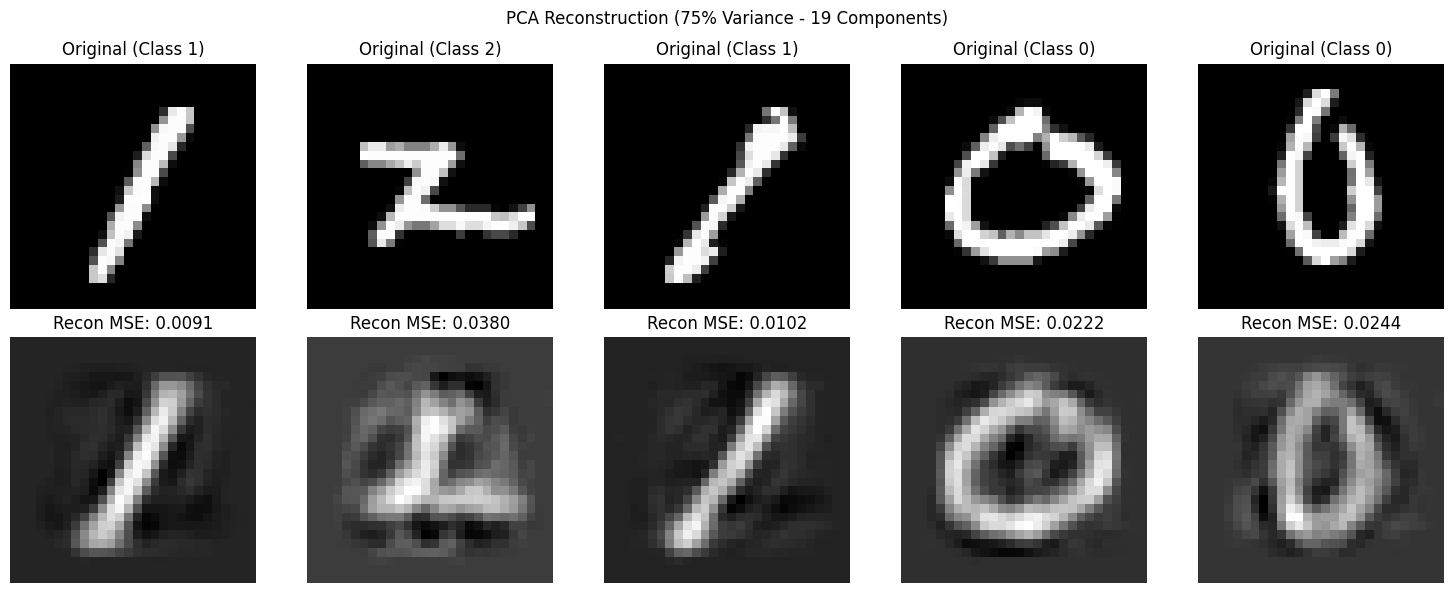

In [11]:
print("\nExecuting PCA...")
# Obtain data matrix X
X = X_train_orig.T
X_test = X_test_orig.T

# Obtain its mean mu
mu = np.mean(X, axis=1, keepdims=True)

# Remove the mean from X to obtain Xc
Xc = X - mu

# Obtain covariance S
S = (Xc @ Xc.T) / (X.shape[1] - 1)

# Obtain eigenvectors and eigenvalues, sort descending
eigenvalues, eigenvectors = np.linalg.eigh(S)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Obtain Up and perform Y = Up^T Xc
total_variance = np.sum(eigenvalues)
explained_variance_ratio = np.cumsum(eigenvalues) / total_variance

p_75 = np.argmax(explained_variance_ratio >= 0.75) + 1
p_90 = np.argmax(explained_variance_ratio >= 0.90) + 1

Up_75 = eigenvectors[:, :p_75]
Up_90 = eigenvectors[:, :p_90]
Up_2 = eigenvectors[:, :2]

Y_75 = Up_75.T @ Xc

# For a new test point xtest, check discriminant values
idx = 0
x_test_point = X_test[:, idx:idx+1]
x_test_c = x_test_point - mu
y_test_point = Up_75.T @ x_test_c

mle_params_75 = compute_mle_estimates(Y_75.T, y_train, [0, 1, 2])

# Use return_scores=True to check which discriminant gives the max value
preds_single, scores_single = classify(y_test_point.T, mle_params_75, method='LDA', return_scores=True)

print(f"\nEvaluating Single Test Point (Index {idx}) using 75% PCA + LDA:")
print(f"True Label: {y_test[idx]}")
print(f"Discriminant Values [Class 0, Class 1, Class 2]: {scores_single[0]}")
print(f"Predicted Class (Max Value): {preds_single[0]}")

# Reconstruct and show 5 samples from test set
test_indices = np.random.choice(X_test.shape[1], 5, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, t_idx in enumerate(test_indices):
    x_orig = X_test[:, t_idx:t_idx+1]
    x_c_test = x_orig - mu
    y_proj = Up_75.T @ x_c_test
    x_recon = (Up_75 @ y_proj) + mu
    
    mse = np.mean((x_orig - x_recon)**2)
    
    # Note: Transpose back (.T) since columns were stacked originally
    img_orig = x_orig.reshape(28, 28).T
    img_recon = x_recon.reshape(28, 28).T
    
    axes[0, i].imshow(img_orig, cmap='gray')
    axes[0, i].set_title(f"Original (Class {y_test[t_idx]})")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(img_recon, cmap='gray')
    axes[1, i].set_title(f"Recon MSE: {mse:.4f}")
    axes[1, i].axis('off')

plt.suptitle(f"PCA Reconstruction (75% Variance - {p_75} Components)")
plt.tight_layout()
plt.show()

### Step 4: Fisher's Discriminant Analysis (FDA)
Computing the Within-Class ($S_W$) and Between-Class ($S_B$) scatter matrices to solve $S_W w = \lambda S_B w$.

In [12]:
print("\nExecuting FDA...")
d, N_total = X.shape
S_W = np.zeros((d, d))
S_B = np.zeros((d, d))

for c in [0, 1, 2]:
    X_c = X[:, y_train == c]
    N_c = X_c.shape[1]
    mu_c = np.mean(X_c, axis=1, keepdims=True)
    
    # Within-class scatter matrix SW
    X_c_centered = X_c - mu_c
    S_W += X_c_centered @ X_c_centered.T
    
    # Between-class scatter matrix SB
    diff = mu_c - mu
    S_B += N_c * (diff @ diff.T)

# Regularization
S_W += 1e-4 * np.eye(d)
    
# Solve generalized eigenvalue problem
# Converting to standard eigenvalue problem using pseudo-inverse
M = np.linalg.pinv(S_W) @ S_B
evals_fda, evecs_fda = np.linalg.eig(M)
evals_fda, evecs_fda = np.real(evals_fda), np.real(evecs_fda)

sorted_fda_indices = np.argsort(evals_fda)[::-1]
W_fda = evecs_fda[:, sorted_fda_indices[:2]]  # Top 2 directions for 3 classes


Executing FDA...


### Step 5: Evaluate and Compare Model Performance
Calculating Train and Test accuracies for all designated models.

In [13]:
def evaluate_model(X_tr, X_te, y_tr, y_te, method):
    mle_params = compute_mle_estimates(X_tr, y_tr, [0, 1, 2])
    preds_tr = classify(X_tr, mle_params, method=method)
    preds_te = classify(X_te, mle_params, method=method)
    return calculate_accuracy(y_tr, preds_tr), calculate_accuracy(y_te, preds_te)

print("\nEvaluation Results")

# FDA Application
Y_fda_train = (W_fda.T @ X).T
Y_fda_test = (W_fda.T @ X_test).T

fda_lda_tr, fda_lda_te = evaluate_model(Y_fda_train, Y_fda_test, y_train, y_test, 'LDA')
fda_qda_tr, fda_qda_te = evaluate_model(Y_fda_train, Y_fda_test, y_train, y_test, 'QDA')

print(f"FDA (2 comps) + LDA -> Train Acc: {fda_lda_tr*100:.2f}%, Test Acc: {fda_lda_te*100:.2f}%")
print(f"FDA (2 comps) + QDA -> Train Acc: {fda_qda_tr*100:.2f}%, Test Acc: {fda_qda_te*100:.2f}%")

# PCA + LDA Applications
def evaluate_pca(Up):
    Y_pca_train = (Up.T @ (X - mu)).T
    Y_pca_test = (Up.T @ (X_test - mu)).T
    return evaluate_model(Y_pca_train, Y_pca_test, y_train, y_test, 'LDA')
    
pca75_lda_tr, pca75_lda_te = evaluate_pca(Up_75)
print(f"PCA (75% Var, {p_75:03d} comps) + LDA -> Train Acc: {pca75_lda_tr*100:.2f}%, Test Acc: {pca75_lda_te*100:.2f}%")

pca90_lda_tr, pca90_lda_te = evaluate_pca(Up_90)
print(f"PCA (90% Var, {p_90:03d} comps) + LDA -> Train Acc: {pca90_lda_tr*100:.2f}%, Test Acc: {pca90_lda_te*100:.2f}%")

pca2_lda_tr, pca2_lda_te = evaluate_pca(Up_2)
print(f"PCA (2 comps) + LDA -> Train Acc: {pca2_lda_tr*100:.2f}%, Test Acc: {pca2_lda_te*100:.2f}%")


Evaluation Results
FDA (2 comps) + LDA -> Train Acc: 100.00%, Test Acc: 88.67%
FDA (2 comps) + QDA -> Train Acc: 100.00%, Test Acc: 88.67%
PCA (75% Var, 019 comps) + LDA -> Train Acc: 97.00%, Test Acc: 94.33%
PCA (90% Var, 051 comps) + LDA -> Train Acc: 99.67%, Test Acc: 96.00%
PCA (2 comps) + LDA -> Train Acc: 92.67%, Test Acc: 92.33%


### Step 6: 2D Feature Space Visualization
The FDA plot heavily demonstrates overfitting to the training set (clusters tightly forced into points). The PCA plot demonstrates natural, broader clustering based strictly on visual variance.

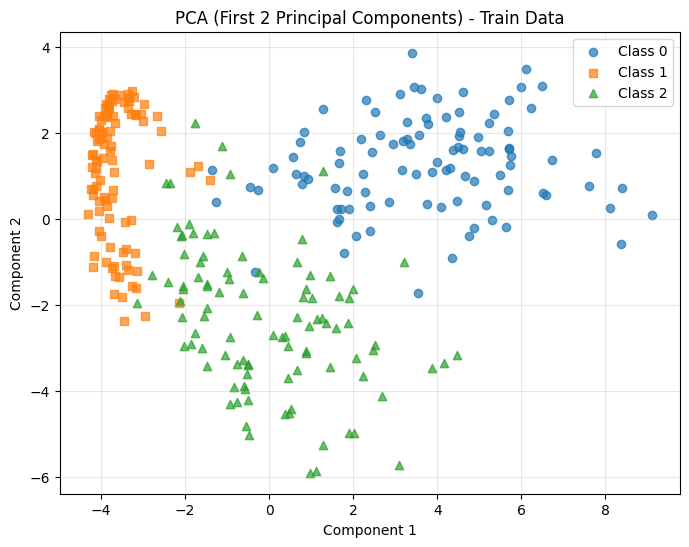

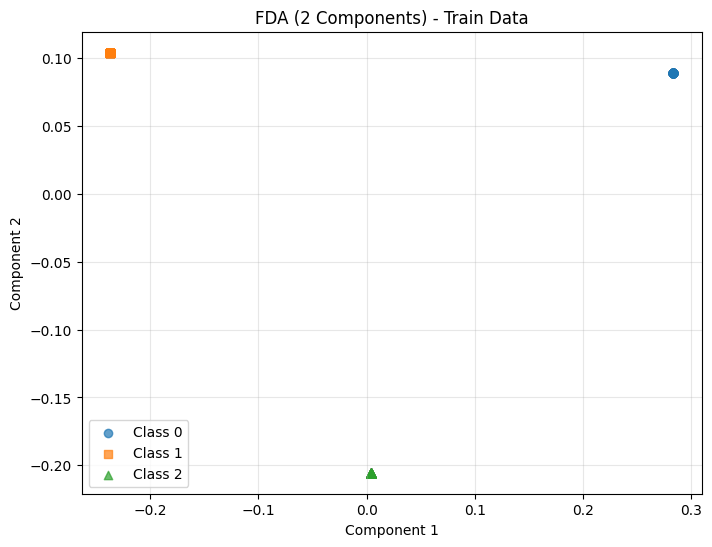

In [14]:
def plot_2d_scatter(Z, labels, title):
    plt.figure(figsize=(8, 6))
    colors =['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['o', 's', '^']
    
    for i, c in enumerate([0, 1, 2]):
        plt.scatter(Z[labels == c, 0], Z[labels == c, 1], 
                    c=colors[i], marker=markers[i], label=f'Class {c}', alpha=0.7)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Y_pca2_train = (Up_2.T @ (X - mu)).T

plot_2d_scatter(Y_pca2_train, y_train, "PCA (First 2 Principal Components) - Train Data")
plot_2d_scatter(Y_fda_train, y_train, "FDA (2 Components) - Train Data")